# Supervised PCA

In this notebook, we use the manifold optimization approach to SPCA on a medical dataset, suitable for regression. 
The full description of this dataset is available on https://archive.ics.uci.edu/dataset/189/parkinsons+telemonitoring.

In [10]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from models import SupervisedPCA, spca_normalized_loss
from utils import load_parkinsons_data, normalize_to_minus1_1
import matplotlib.pyplot as plt
import torch
import numpy as np

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [12]:
# Prepare data
X, y, feature_names = load_parkinsons_data(device)

# Center features
X = X - X.mean(dim=0)
y = y - y.mean(dim=0)

# Normalize features
X = normalize_to_minus1_1(X)
y = normalize_to_minus1_1(y)

print(X.shape)
print(y.shape)

torch.Size([1000, 19])
torch.Size([1000, 1])


## Model training
We train the model for different lambdas and keep the one with the best normalized loss.

Smaller lambda puts more weight onto the supervised (prediction) error while a larger lambda puts more weight on the unsupervised (reconstruction) error in the loss function

In [13]:
lambda_candidates = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
best_lambda = None
best_loss = float('inf')
best_model = None
res = []

for lam in lambda_candidates:
    # Initialize a fresh model for each lambda
    model = SupervisedPCA(input_dim=X.shape[1], output_dim=2)
    
    # Train L for this lambda
    print(f"performing SPCA on lambda {lam}")
    model.train(X, y, lam=lam, steps=200)

    # Compute normalized loss
    pred_loss, recon_loss = spca_normalized_loss(X, y, model.L)

    # Save results
    res.append({"lam": lam, "pred_loss": pred_loss.item(), "recon_loss": recon_loss.item(), "history": model.loss_history})

performing SPCA on lambda 0.001
Step 0: loss = 318.5650
Step 10: loss = 226.6114
Step 20: loss = 223.0873
Step 30: loss = 221.0411
Step 40: loss = 218.4721
Step 50: loss = 216.7214
Step 60: loss = 216.4111
Step 70: loss = 216.1770
Step 80: loss = 215.9677
Step 90: loss = 215.8016
Step 100: loss = 215.6506
Step 110: loss = 215.5386
Step 120: loss = 215.4080
Step 130: loss = 215.3073
Step 140: loss = 215.2361
Step 150: loss = 215.1339
Step 160: loss = 215.0524
Step 170: loss = 214.9684
Step 180: loss = 214.8936
Step 190: loss = 214.8232
performing SPCA on lambda 0.01
Step 0: loss = 332.4944
Step 10: loss = 239.1380
Step 20: loss = 236.4748
Step 30: loss = 234.7331
Step 40: loss = 232.0722
Step 50: loss = 230.9810
Step 60: loss = 230.6495
Step 70: loss = 230.4262
Step 80: loss = 230.2139
Step 90: loss = 230.0437
Step 100: loss = 229.9047
Step 110: loss = 229.7717
Step 120: loss = 229.6475
Step 130: loss = 229.5535
Step 140: loss = 229.4649
Step 150: loss = 229.3789
Step 160: loss = 229.29

## Visualize results

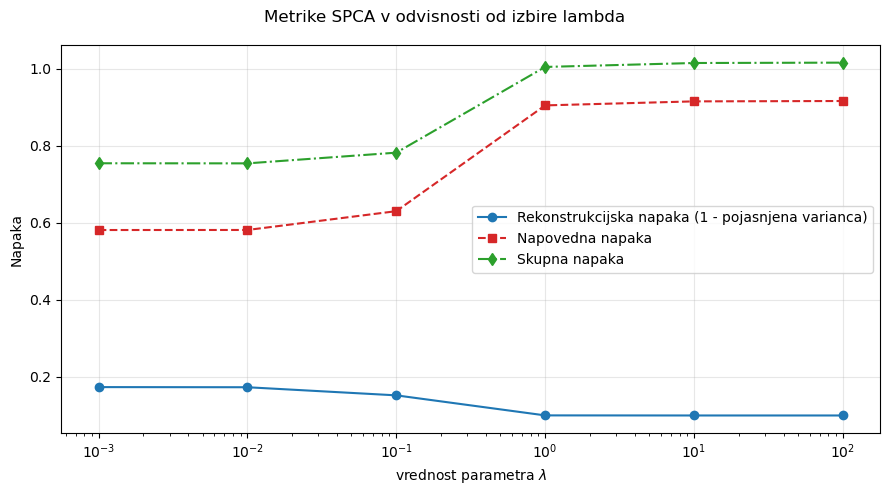

In [14]:
lams = [r["lam"] for r in res]
pred = [float(r["pred_loss"]) for r in res]
recon = [float(r["recon_loss"]) for r in res]
total_norm = [p + r for p, r in zip(pred, recon)]

fig, ax = plt.subplots(figsize=(9, 5))

ax.semilogx(lams, recon, 'o-', color='tab:blue', label='Rekonstrukcijska napaka (1 - pojasnjena varianca)')
ax.semilogx(lams, pred, 's--', color='tab:red', label='Napovedna napaka')
ax.semilogx(lams, total_norm, 'd-.', color='tab:green', label='Skupna napaka')

ax.set_xlabel(r'vrednost parametra $\lambda$')
ax.set_ylabel('Napaka')
ax.grid(True, alpha=0.3)
ax.legend(loc='center right')

fig.suptitle('Metrike SPCA v odvisnosti od izbire lambda')
plt.tight_layout()
plt.savefig("../final_vizualizations/spca_metrics_by_lambda.svg", format="svg", bbox_inches="tight")
plt.savefig("../final_vizualizations/spca_metrics_by_lambda.png", format="png", bbox_inches="tight", dpi=150)
plt.show()

A lower choice of lambda seems to work better, with Prediction loss significantly lower and Reconstruction loss only slightly higher.

Let's continue with lam=0.01

Step 0: loss = 332.4944
Step 10: loss = 239.1380
Step 20: loss = 236.4748
Step 30: loss = 234.7331
Step 40: loss = 232.0722
Step 50: loss = 230.9810
Step 60: loss = 230.6495
Step 70: loss = 230.4262
Step 80: loss = 230.2139
Step 90: loss = 230.0437
Step 100: loss = 229.9047
Step 110: loss = 229.7717
Step 120: loss = 229.6475
Step 130: loss = 229.5535
Step 140: loss = 229.4649
Step 150: loss = 229.3789
Step 160: loss = 229.2997
Step 170: loss = 229.2382
Step 180: loss = 229.1600
Step 190: loss = 229.1015


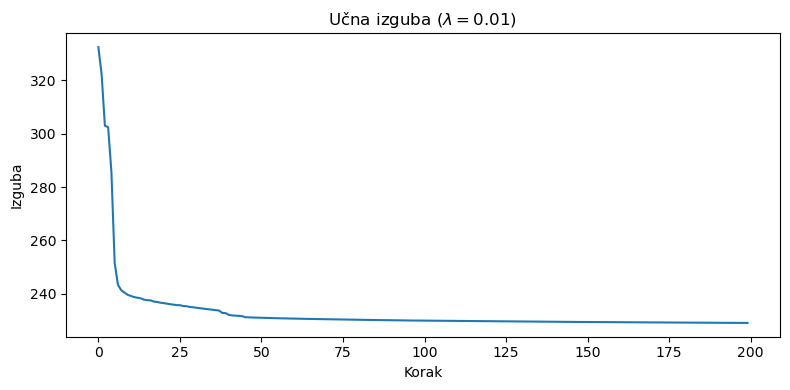

In [15]:
model = SupervisedPCA(input_dim=X.shape[1], output_dim=2)
model.train(X, y, lam=0.01, steps=200)

plt.figure(figsize=(8, 4))
plt.plot(model.loss_history)
plt.xlabel("Korak")
plt.ylabel("Izguba")
plt.title(r"Učna izguba ($\lambda = 0.01$)")
plt.tight_layout()
plt.savefig("../final_vizualizations/spca_training_loss.svg", format="svg", bbox_inches="tight")
plt.savefig("../final_vizualizations/spca_training_loss.png", format="png", bbox_inches="tight")
plt.show()

To better understand the results, let's visualize the first two supervised principal components with a random sample of 100 projections, color-graded by their target value.

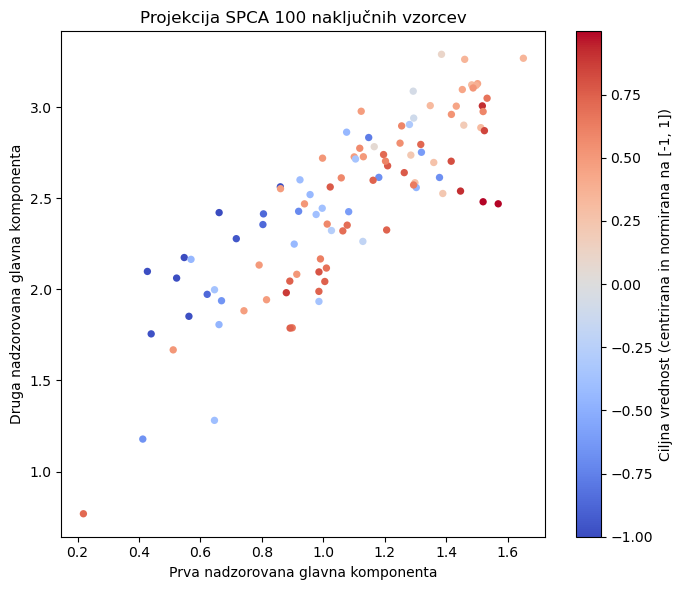

In [16]:
torch.manual_seed(0)
idx = torch.randperm(X.shape[0], device=X.device)[:100]
X_s = X[idx]
y_s = y[idx].squeeze(-1)

L = model.L.detach()
proj = X_s @ L

plt.figure(figsize=(7, 6))
sc = plt.scatter(
    proj[:, 0].cpu().numpy(),
    proj[:, 1].cpu().numpy(),
    c=y_s.cpu().numpy(),
    cmap="coolwarm",
    s=28,
    edgecolors="none",
)
plt.colorbar(sc, label="Ciljna vrednost (centrirana in normirana na [-1, 1])")
plt.xlabel("Prva nadzorovana glavna komponenta")
plt.ylabel("Druga nadzorovana glavna komponenta")
plt.title("Projekcija SPCA 100 naključnih vzorcev")
plt.tight_layout()
plt.savefig("../final_vizualizations/spca_projection.svg", format="svg", bbox_inches="tight")
plt.savefig("../final_vizualizations/spca_projection.png", format="png", bbox_inches="tight")
plt.show()

It can be seen that the top right corner (Component 1 high and Component 2 high) is a solid predictor for higher target values and the lower left corner (Component 1 low and Component 2 low) for lower values.

To better understand the composition of the first two principle components, let's look at them as a weighted sum of the original features (loadings).

In [17]:
L_np = model.L.detach().cpu().numpy()
top_k = 5
for j in range(L_np.shape[1]):
    order = np.argsort(-np.abs(L_np[:, j]))
    print(f"Top {top_k} weighted fetures in component {j + 1}:")
    for rank, i in enumerate(order[:top_k], start=1):
        print(f"  {rank}. {L_np[i, j]:+.2f} * {feature_names[i]}")
    print()

Top 5 weighted fetures in component 1:
  1. -0.43 * Jitter:PPQ5
  2. -0.42 * Jitter(Abs)
  3. -0.31 * Shimmer
  4. -0.29 * Shimmer(dB)
  5. +0.28 * Shimmer:APQ5

Top 5 weighted fetures in component 2:
  1. -0.43 * Shimmer:APQ5
  2. -0.39 * Jitter:RAP
  3. -0.39 * Jitter:DDP
  4. -0.32 * sex
  5. -0.31 * Shimmer:APQ11

